# Taller 05 — Clasificación de texto en español con RNN

**Curso:** Procesamiento de Lenguaje Natural — Pontificia Universidad Javeriana
**Repositorio:** https://github.com/davidm094/NLP_JAVE_TALLER05_202601

Este notebook adapta el ejemplo de clase (*Text classification with an RNN*, TensorFlow) al dataset de salud mental en español
(`statement_es_es`). Se resuelven dos tareas:

* **Binaria:** Normal vs Depression.
* **Multiclase:** 7 clases (Anxiety, Bipolar, Depression, Normal, Personality disorder, Stress, Suicidal).

El código reutilizable está en `src/` y el diseño experimental en `DISENO_EXPERIMENTAL.md`. Aquí se (1) explora el dataset,
(2) se entrena en vivo la RNN base, y (3) se analizan las corridas del barrido de hiperparámetros guardadas en `results/`.

In [1]:
import sys, json
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np, pandas as pd, tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import Image, display
from datos import cargar, split_binario, split_multiclase, TEXTO
from modelo import vectorizar, construir, optimizador
from entrenar import BASE
print("TensorFlow", tf.__version__)

I0000 00:00:1791466957.456901    1884 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791466957.498388    1884 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791466958.587399    1884 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Datos
Solo se usa el texto en español. Hay 53.043 filas; 45 tienen el texto vacío.

In [2]:
df = cargar()
print(df.shape)
print(df.status.value_counts())
largo = df[TEXTO].fillna("").str.split().str.len()
print("\nPalabras por texto:")
print(largo.describe(percentiles=[.5, .9, .95, .99]).round(1))

(53043, 3)
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64



Palabras por texto:
count    53043.0
mean        89.4
std        127.2
min          0.0
50%         52.0
90%        215.8
95%        296.0
99%        534.0
max       5087.0
Name: statement_es_es, dtype: float64


## 2. Particiones
* **Binaria:** solo filas Normal y Depression (31.755). Test = 20 % (`random_state=42`); del 80 % restante se separa 10 % para validación.
* **Multiclase:** 7 clases, split estratificado 70 / 10 / 20.

La **validación** se usa para early stopping y para elegir hiperparámetros; el **test** solo se reporta.

In [3]:
for nombre, f in [("binaria", split_binario), ("multiclase", split_multiclase)]:
    tr, va, te, clases = f()
    print(f"{nombre:10s} train={len(tr):6d} val={len(va):5d} test={len(te):6d}  clases={clases}")

binaria    train= 22863 val= 2541 test=  6351  clases=['Normal', 'Depression']


multiclase train= 37098 val= 5300 test= 10600  clases=['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## 3. Codificación del texto (`TextVectorization`)
Responde a las preguntas del notebook de clase:

* **¿Qué es esto?** `TextVectorization` aprende un vocabulario (las `max_tokens` palabras más frecuentes **del train**) y convierte cada texto en
  una secuencia de índices enteros. El índice 0 es relleno (*padding*) y el 1 es `[UNK]` (palabra fuera del vocabulario).
* **¿La matriz tiene número fijo de filas y columnas?** Las filas = número de textos del lote. Las columnas: en el notebook original **no** son
  fijas (se rellena hasta el texto más largo de cada lote); aquí se fijan con `output_sequence_length=max_len` (128 en la base), truncando los
  textos largos y rellenando los cortos con ceros.

La estandarización se ajustó para español: además de minúsculas y puntuación, se quitan `¿ ¡ « »`.

In [4]:
tr, va, te, clases = split_binario()
textos = [d[TEXTO].fillna("").astype(str).tolist() for d in (tr, va, te)]
enc, (Xtr, Xva, Xte) = vectorizar(textos[0], textos, vocab=BASE["vocab"], max_len=BASE["max_len"])
vocab = np.array(enc.get_vocabulary())
print("Primeros 20 tokens:", vocab[:20])
print("Forma de la matriz de train:", Xtr.shape)
ej = textos[0][0]
print("\nOriginal :", ej[:300])
print("Ida y vuelta:", " ".join(vocab[Xtr[0]][Xtr[0] > 0])[:300])

Primeros 20 tokens: ['' '[UNK]' 'que' 'de' 'y' 'no' 'a' 'me' 'la' 'en' 'mi' 'el' 'un' 'es'
 'pero' 'por' 'lo' 'para' 'con' 'una']
Forma de la matriz de train: (22863, 128)

Original : ¿qué crees que es?
Ida y vuelta: qué crees que es


## 4. Modelo base
Misma arquitectura del ejemplo de clase: `Embedding → Bidirectional(LSTM 64) → Dense(64, relu) → Dense(salida)`, con `mask_zero=True`
para que la RNN ignore el relleno. Diferencias justificadas: vocabulario de 10.000 (en vez de 1.000), Adam con lr 1e-3 (en vez de 1e-4) y
early stopping sobre la pérdida de validación.

In [5]:
print({k: BASE[k] for k in ["celda", "bidireccional", "vocab", "emb_dim", "unidades", "capas", "dropout", "dense", "lr", "batch", "max_len"]})
tf.keras.utils.set_random_seed(42)
modelo = construir(BASE, len(vocab), n_clases=2)
modelo.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
               optimizer=optimizador("adam", BASE["lr"]), metrics=["accuracy"])
modelo.build((None, Xtr.shape[1]))
modelo.summary()

{'celda': 'lstm', 'bidireccional': True, 'vocab': 10000, 'emb_dim': 64, 'unidades': 64, 'capas': 1, 'dropout': 0.0, 'dense': 64, 'lr': 0.001, 'batch': 64, 'max_len': 128}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,369 (2.73 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento en vivo (binaria, semilla 42)
Tarda ~2–3 minutos en CPU.

Epoch 1/20


E0000 00:00:1791466967.625686    1884 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


358/358 - 30s - 84ms/step - accuracy: 0.9022 - loss: 0.2425 - val_accuracy: 0.9351 - val_loss: 0.1673


Epoch 2/20


358/358 - 26s - 74ms/step - accuracy: 0.9575 - loss: 0.1185 - val_accuracy: 0.9425 - val_loss: 0.1817


Epoch 3/20


358/358 - 26s - 73ms/step - accuracy: 0.9761 - loss: 0.0757 - val_accuracy: 0.9355 - val_loss: 0.2039


Epoch 4/20


358/358 - 41s - 114ms/step - accuracy: 0.9847 - loss: 0.0476 - val_accuracy: 0.9339 - val_loss: 0.2484


Test accuracy: 0.9449


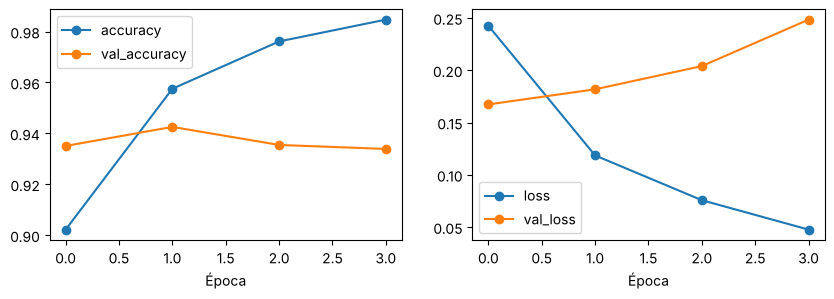

In [6]:
hist = modelo.fit(Xtr, tr.y.values, validation_data=(Xva, va.y.values), epochs=20, batch_size=BASE["batch"],
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
                  verbose=2)
perdida, acc = modelo.evaluate(Xte, te.y.values, verbose=0)
print(f"Test accuracy: {acc:.4f}")
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
for ax, m in zip(axs, ["accuracy", "loss"]):
    ax.plot(hist.history[m], "-o", label=m); ax.plot(hist.history["val_" + m], "-o", label="val_" + m)
    ax.set_xlabel("Época"); ax.legend()
plt.show()

> **Nota:** esta corrida en vivo puede diferir unas décimas de punto de las corridas guardadas en `results/` (accuracy de test de la base: 0,9452–0,9496 en 3 semillas). Aunque la semilla es la misma, el orden en que se inicializan las capas cambia los pesos iniciales. Esa variación es justamente el **ruido entre semillas** que el diseño experimental mide y usa como umbral.

La pérdida de validación toca su mínimo en la época 1–2 y luego sube mientras la de entrenamiento sigue bajando: **sobreajuste temprano**.
`restore_best_weights=True` devuelve los pesos de la mejor época.

### Predicción sobre textos nuevos
Salida > 0 ⇒ Depression; < 0 ⇒ Normal (logit).

In [7]:
nuevos = ["hoy fue un buen día, salí con mis amigos y me reí mucho",
          "no tengo ganas de nada, me siento vacío y cansado todo el tiempo",
          "tengo que entregar el informe mañana y todavía no termino"]
logits = modelo.predict(enc(tf.constant(nuevos)), verbose=0)[:, 0]
for t, z in zip(nuevos, logits):
    print(f"{z:+.2f}  {'Depression' if z >= 0 else 'Normal':10s}  {t}")

-3.93  Normal      hoy fue un buen día, salí con mis amigos y me reí mucho
+0.91  Depression  no tengo ganas de nada, me siento vacío y cansado todo el tiempo
-4.34  Normal      tengo que entregar el informe mañana y todavía no termino


## 6. Diseño experimental y resultados del barrido
Las corridas se hicieron con `src/experimentos.py` y `src/correr.py` (una configuración por corrida) y quedaron en `results/`.

* **Base binaria:** la del punto 4, 3 semillas.
* **Base multiclase:** la misma arquitectura **con pesos de clase** (reducen el ruido entre semillas ~3×), 3 semillas, paciencia 1.
* **Factores:** 9 variaciones, una a la vez. Un efecto es "real" si |Δ F1 val| > 2σ (σ = desviación estándar entre semillas de la base).

In [8]:
import importlib, figuras
importlib.reload(figuras)
b, m = figuras.cargar()
t = figuras.tabla_efectos(b, m)
t[["tarea", "etiqueta", "val_f1", "delta_pp", "delta_sigma", "veredicto", "test_acc", "tiempo_s"]].round(3)

,tarea,etiqueta,val_f1,delta_pp,delta_sigma,veredicto,test_acc,tiempo_s
0,binaria,GRU (vs LSTM),0.944,0.417,2.683,mejora,0.952,126.5
1,binaria,SimpleRNN (vs LSTM),0.932,-0.773,-4.971,empeora,0.934,91.8
2,binaria,Unidireccional,0.937,-0.250,-1.604,ruido,0.948,77.6
3,binaria,128 unidades (vs 64),0.942,0.219,1.408,ruido,0.940,249.9
4,binaria,2 capas (vs 1),0.943,0.381,2.452,mejora,0.948,307.1
5,binaria,"Dropout 0,2 (vs 0)",0.939,-0.063,-0.407,ruido,0.945,153.0
6,binaria,lr 3e-4 (vs 1e-3),0.943,0.336,2.162,mejora,0.947,195.6
7,binaria,Vocabulario 1.000 (vs 10.000),0.940,0.105,0.677,ruido,0.946,161.9
8,binaria,256 tokens (vs 128),0.935,-0.464,-2.985,empeora,0.944,330.4
9,multiclase,GRU (vs LSTM),0.636,1.982,1.731,ruido,0.694,213.5


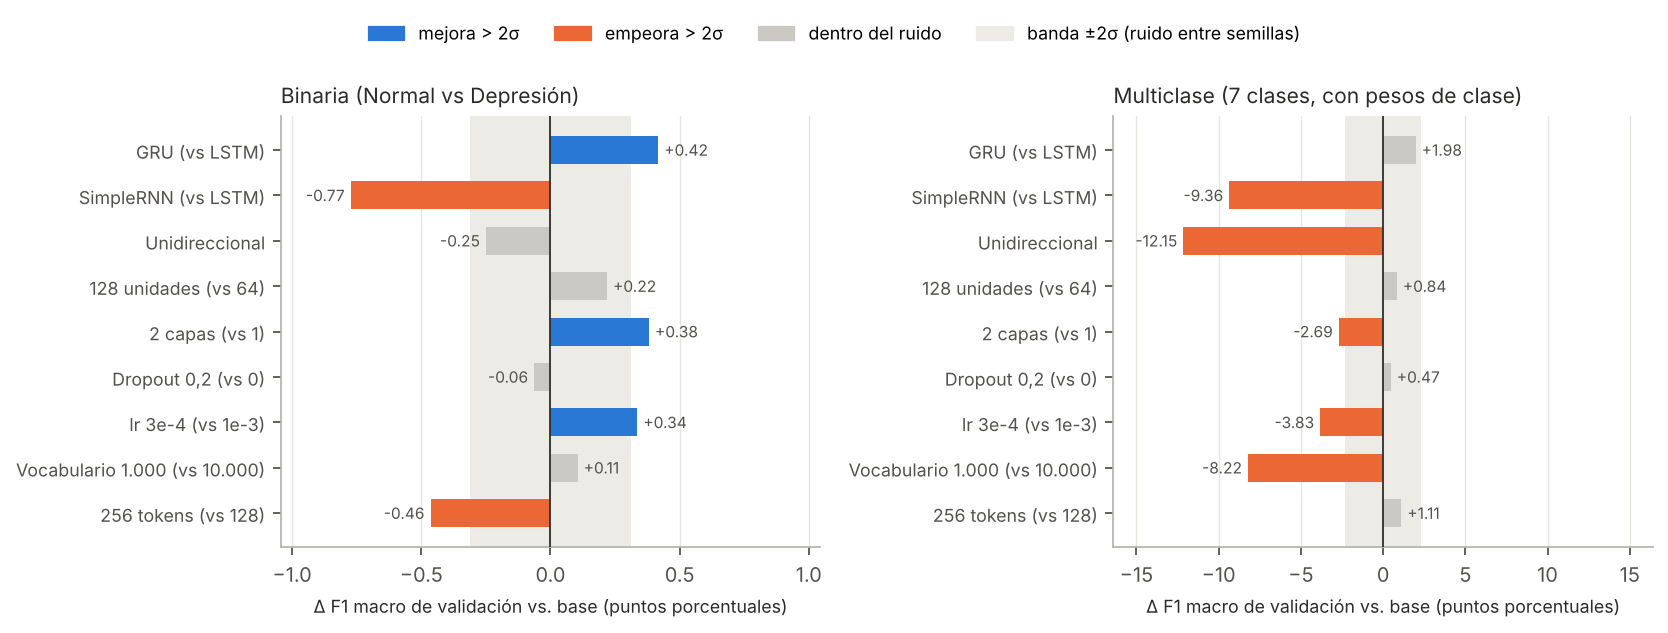

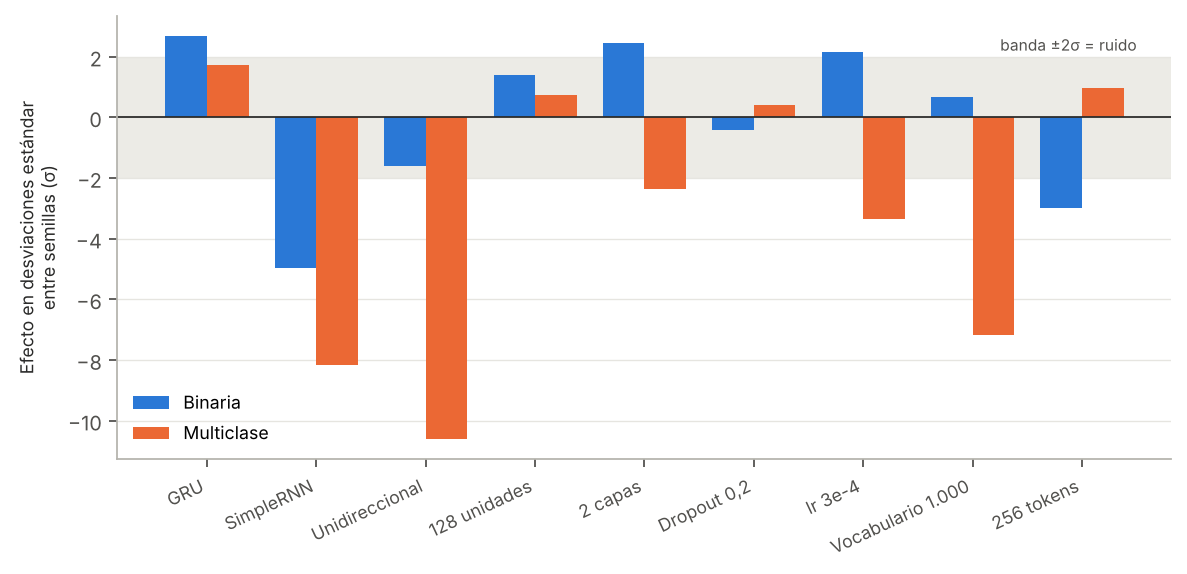

In [9]:
figuras.fig_efectos_pp(t); figuras.fig_efectos_sigma(t)
display(Image(str(RAIZ / "figs" / "efectos_por_factor.png")))
display(Image(str(RAIZ / "figs" / "binaria_vs_multiclase_sigma.png")))

### Ruido entre semillas y efecto de los pesos de clase

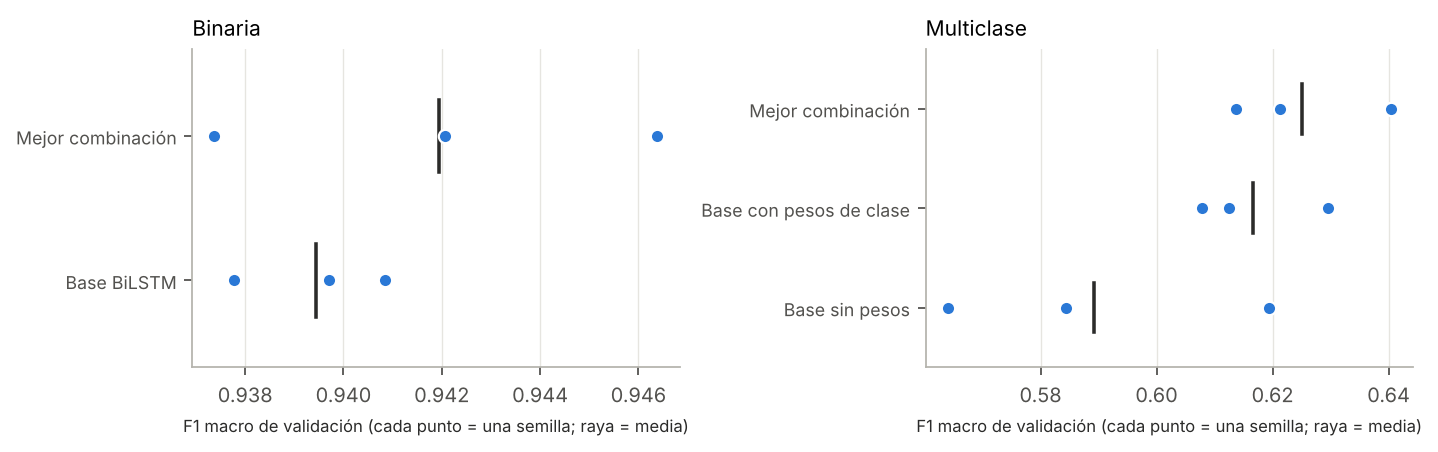

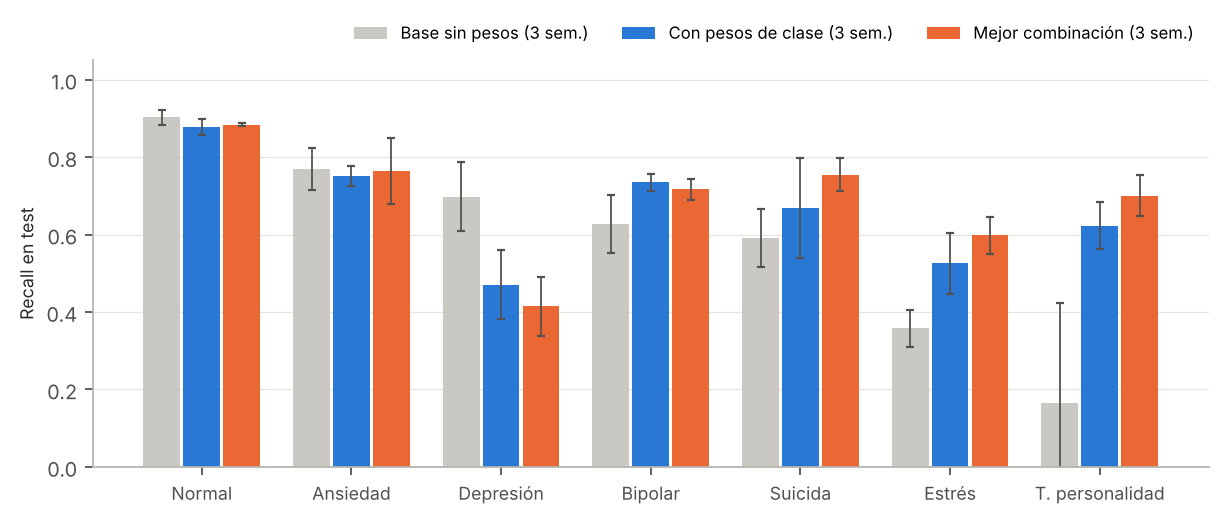

In [10]:
figuras.fig_semillas(b, m); figuras.fig_recall_clases(m)
display(Image(str(RAIZ / "figs" / "variabilidad_semillas.png")))
display(Image(str(RAIZ / "figs" / "recall_por_clase.png")))

### Base vs mejor combinación (3 semillas cada una)

In [11]:
figuras.resumen_mejor(b, m).round(4)

,tarea,modelo,n,val_f1_macro_media,test_accuracy_media,test_f1_macro_media,tiempo_s_media,val_f1_macro_de,test_accuracy_de,test_f1_macro_de
0,binaria,base,3,0.9394,0.9476,0.9476,147.5333,0.0016,0.0022,0.0022
1,binaria,mejor,3,0.9419,0.9476,0.9476,377.4000,0.0045,0.0027,0.0027
2,multiclase,base,3,0.6166,0.6771,0.6155,222.8333,0.0115,0.0073,0.0088
3,multiclase,mejor,3,0.6252,0.6856,0.6309,443.7667,0.0137,0.0142,0.0115


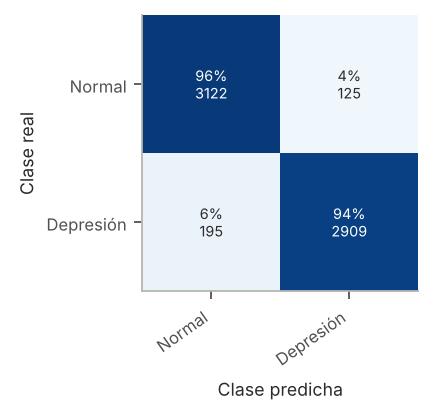

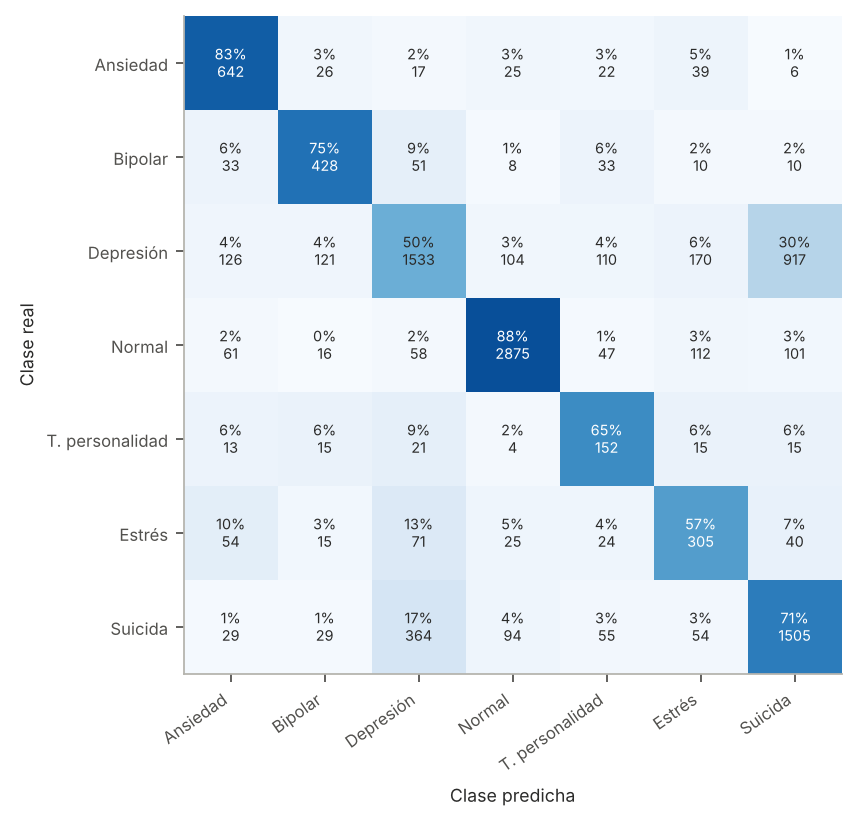

In [12]:
figuras.fig_confusion("binaria", "base_s42", "confusion_binaria.png")
figuras.fig_confusion("multiclase", "mejor_s42", "confusion_multiclase.png")
display(Image(str(RAIZ / "figs" / "confusion_binaria.png")))
display(Image(str(RAIZ / "figs" / "confusion_multiclase.png")))

## 7. Conclusiones
Ver el reporte PDF para la discusión completa. En resumen:

1. **Binaria:** problema fácil y casi insensible a los hiperparámetros (todos los efectos en ±0,8 pp). La base ya está en el techo (~0,948 de accuracy en test); la mejor combinación no la supera.
2. **Multiclase:** mucho más difícil (F1 macro ~0,62) y sensible: bidireccionalidad, celda con compuertas (LSTM/GRU) y vocabulario suficiente son determinantes.
3. **Desbalance:** sin pesos de clase la clase minoritaria (Personality disorder, 2 %) se detecta o no según la semilla; los pesos de clase lo estabilizan a costa de ~3,5 pp de accuracy.
4. **GRU** es la única variación que mejora (o no empeora) en ambas tareas y entrena más rápido que LSTM.